# Results Analysis and Discussion

This notebook aggregates all model results from notebooks 02 and 03 and performs:

1. **Overall performance summary** – unified metrics table across all models
2. **Cross-modal disagreement analysis** – identify utterances where text and audio/visual signals conflict
3. **Hypothesis testing** – verify the three hypotheses stated in the project introduction

### Hypotheses
| # | Hypothesis |
|---|------------|
| H1 | Text-only models systematically underperform on utterances with extreme sentiment values (\|score\| > 2), as strong emotions rely on prosodic and facial cues inaccessible from text alone. |
| H2 | The gain from adding acoustic/visual modalities is largest for *near-neutral* utterances, where textual sentiment is most ambiguous. |
| H3 | Cross-modal disagreement (text vs. audio/visual sentiment signal) is negatively correlated with label intensity – extreme-sentiment utterances tend to show *more* cross-modal agreement than neutral ones. |

In [1]:
import sys
import os
import random
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import f1_score

MULTIBENCH = os.path.join("..", "external", "MultiBench")
sys.path.insert(0, MULTIBENCH)
from datasets.affect.get_data import get_dataloader

import torch
import torch.nn as nn

# --- reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("../figures", exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete  |  seed: {SEED}")

Setup complete  |  seed: 42


In [2]:
# --- Load saved results ---
with open("../results/text_model_results.pkl", "rb") as f:
    text_results = pickle.load(f)

with open("../results/multimodal_results.pkl", "rb") as f:
    mm_results = pickle.load(f)

all_results = {**text_results, **mm_results}

print("Loaded models:", list(all_results.keys()))

Loaded models: ['Ridge', 'SVR', 'BiLSTM', 'Transformer', 'BiLSTM (audio)', 'BiLSTM (vision)', 'Early Fusion', 'Late Fusion', 'LRTF']


## 1. Overall Performance Summary

In [3]:
def compute_metrics(preds, labels):
    preds  = np.array(preds)
    labels = np.array(labels)
    mae  = np.mean(np.abs(preds - labels))
    mse  = np.mean((preds - labels) ** 2)
    corr = pearsonr(preds, labels)[0]
    nz   = labels != 0
    preds_bin  = (preds[nz]  > 0).astype(int)
    labels_bin = (labels[nz] > 0).astype(int)
    acc2 = np.mean(preds_bin == labels_bin)
    f1   = f1_score(labels_bin, preds_bin, average='weighted')
    return {"MAE": mae, "MSE": mse, "Pearson_r": corr, "Acc_2": acc2, "F1": f1}

# Build summary table
rows = {}
for name, res in all_results.items():
    p, l = res['preds'], res['labels']
    rows[name] = compute_metrics(p, l)

df_all = pd.DataFrame(rows).T[["MAE", "MSE", "Pearson_r", "Acc_2", "F1"]]

# Highlight best per column
def highlight_best(df):
    best_row = {col: (df[col].idxmin() if col in ['MAE','MSE'] else df[col].idxmax())
                for col in df.columns}
    out = df.round(4).copy()
    for col, row in best_row.items():
        out.loc[row, col] = f"**{out.loc[row, col]}**"
    return out

print(df_all.round(4).to_string())
print("\n(Bold = best per column)")
print(highlight_best(df_all).to_string())

                    MAE     MSE  Pearson_r   Acc_2      F1
Ridge            0.7140  0.8446     0.5592  0.7881  0.7881
SVR              0.6620  0.7629     0.6154  0.7892  0.7877
BiLSTM           0.6170  0.6910     0.6620  0.7942  0.7884
Transformer      0.6476  0.7417     0.6335  0.7834  0.7747
BiLSTM (audio)   0.8139  1.1635     0.2407  0.6401  0.6056
BiLSTM (vision)  0.8076  1.1535     0.2509  0.6425  0.6282
Early Fusion     0.6399  0.7390     0.6378  0.7867  0.7781
Late Fusion      0.6111  0.6764     0.6749  0.8080  0.8072
LRTF             0.6172  0.6897     0.6728  0.8119  0.8104

(Bold = best per column)
                        MAE         MSE   Pearson_r       Acc_2          F1
Ridge                 0.714      0.8446      0.5592      0.7881      0.7881
SVR                   0.662      0.7629      0.6154      0.7892      0.7877
BiLSTM                0.617       0.691       0.662      0.7942      0.7884
Transformer          0.6476      0.7417      0.6335      0.7834      0.7747
BiLS

/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/422177251.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '**0.6111**' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[row, col] = f"**{out.loc[row, col]}**"
/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/422177251.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '**0.6764**' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[row, col] = f"**{out.loc[row, col]}**"
/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/422177251.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '**0.6749**' has dtype incompatible with float64, please explicitly 

/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/1280990043.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=30, ha='right')
/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/1280990043.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=30, ha='right')
/var/folders/zg/rg2_4mpd0m3f5zjhk_xzmhy00000gn/T/ipykernel_56912/1280990043.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=30, ha='right')


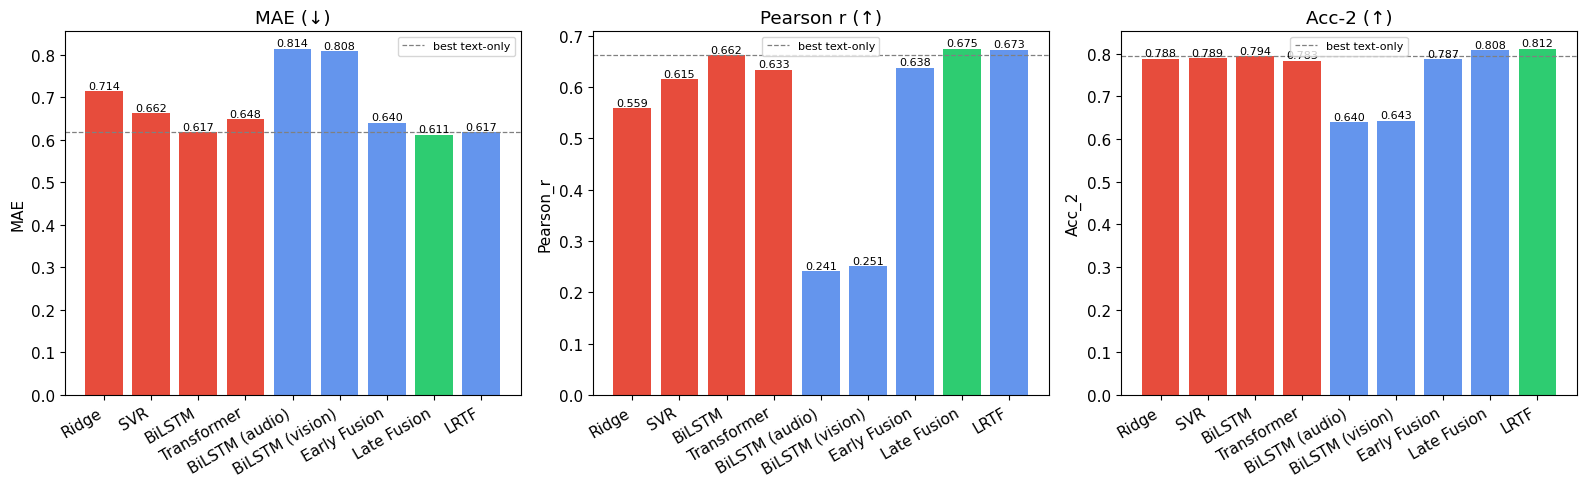

In [4]:
# Visual comparison bar chart
model_names  = list(df_all.index)
metric_names = ["MAE", "Pearson_r", "Acc_2"]
titles       = ["MAE (↓)", "Pearson r (↑)", "Acc-2 (↑)"]
best_fns     = [min, max, max]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title, best_fn in zip(axes, metric_names, titles, best_fns):
    vals   = df_all[metric].values
    best_v = best_fn(vals)
    colors = ['#2ecc71' if v == best_v else
              ('#e74c3c' if i < 4 else 'cornflowerblue')
              for i, v in enumerate(vals)]
    bars = ax.bar(model_names, vals, color=colors)
    ax.set_xticklabels(model_names, rotation=30, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f"{v:.3f}", ha='center', va='bottom', fontsize=8)
    # Dashed line: text-only best
    text_only_vals = [df_all.loc[n, metric] for n in ['Ridge','SVR','BiLSTM','Transformer']
                      if n in df_all.index]
    if text_only_vals:
        ax.axhline(best_fn(text_only_vals), color='grey', linestyle='--',
                   linewidth=0.9, label='best text-only')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/12_all_models_comparison.png", bbox_inches='tight')
plt.show()

## 2. Cross-Modal Disagreement Analysis

The research question asks whether visual and textual sentiment signals agree. We now have three unimodal models—text, audio, and visual BiLSTM—trained on identical architectures, making their per-sample predictions directly comparable.

We define **cross-modal disagreement** between modalities $m_1$ and $m_2$ for sample $i$ as:

$$\Delta_i^{(m_1, m_2)} = |\hat{y}_i^{(m_1)} - \hat{y}_i^{(m_2)}|$$

Three pairwise comparisons are computed:
- Text vs Visual (core research question)
- Text vs Audio
- Audio vs Visual

In [5]:
preds_text   = all_results['BiLSTM']['preds']
preds_audio  = all_results['BiLSTM (audio)']['preds']
preds_vision = all_results['BiLSTM (vision)']['preds']
labels       = all_results['BiLSTM']['labels']

disagree_tv = np.abs(preds_text  - preds_vision)  # text vs visual
disagree_ta = np.abs(preds_text  - preds_audio)   # text vs audio
disagree_av = np.abs(preds_audio - preds_vision)  # audio vs visual

print("Mean cross-modal disagreement:")
print(f"  Text vs Visual : {disagree_tv.mean():.4f}  (std={disagree_tv.std():.4f})")
print(f"  Text vs Audio  : {disagree_ta.mean():.4f}  (std={disagree_ta.std():.4f})")
print(f"  Audio vs Visual: {disagree_av.mean():.4f}  (std={disagree_av.std():.4f})")

Mean cross-modal disagreement:
  Text vs Visual : 0.5259  (std=0.5450)
  Text vs Audio  : 0.5041  (std=0.5461)
  Audio vs Visual: 0.2081  (std=0.1790)


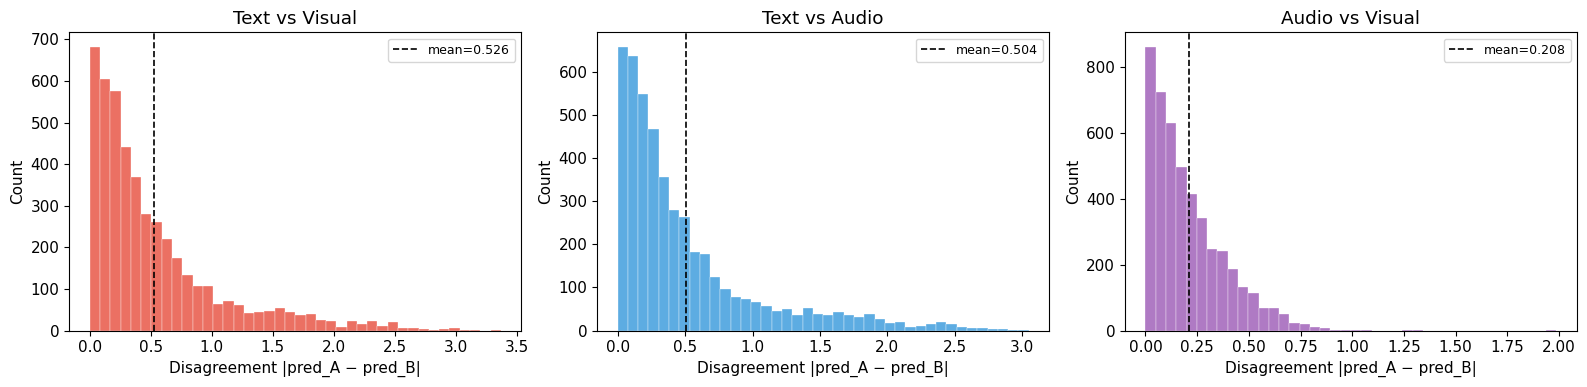

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pairs = [
    ("Text vs Visual",  disagree_tv, '#e74c3c'),
    ("Text vs Audio",   disagree_ta, '#3498db'),
    ("Audio vs Visual", disagree_av, '#9b59b6'),
]

for ax, (title, diss, color) in zip(axes, pairs):
    ax.hist(diss, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(diss.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={diss.mean():.3f}')
    ax.set_xlabel("Disagreement |pred_A − pred_B|")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/13_pairwise_disagreement_dist.png", bbox_inches='tight')
plt.show()

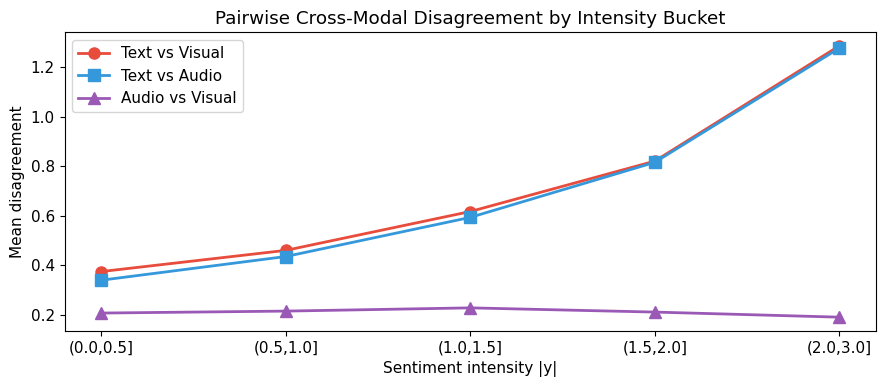

Pearson r(|label|, disagreement):
  Text vs Visual      r=+0.4523  p=0.0000
  Text vs Audio       r=+0.4629  p=0.0000
  Audio vs Visual     r=+0.0263  p=0.0734


In [7]:
# --- Disagreement vs sentiment intensity (per bucket, all three pairs) ---
bucket_edges  = [0, 0.5, 1.0, 1.5, 2.0, 3.0]
bucket_labels = [f"({bucket_edges[i]:.1f},{bucket_edges[i+1]:.1f}]"
                 for i in range(len(bucket_edges)-1)]

def bucket_means(diss):
    vals = []
    for lo, hi in zip(bucket_edges[:-1], bucket_edges[1:]):
        mask = (np.abs(labels) > lo) & (np.abs(labels) <= hi)
        vals.append(diss[mask].mean() if mask.sum() > 0 else np.nan)
    return vals

tv_means = bucket_means(disagree_tv)
ta_means = bucket_means(disagree_ta)
av_means = bucket_means(disagree_av)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(bucket_labels))
ax.plot(x, tv_means, 'o-', color='#e74c3c', linewidth=2, markersize=8, label='Text vs Visual')
ax.plot(x, ta_means, 's-', color='#3498db', linewidth=2, markersize=8, label='Text vs Audio')
ax.plot(x, av_means, '^-', color='#9b59b6', linewidth=2, markersize=8, label='Audio vs Visual')
ax.set_xticks(x)
ax.set_xticklabels(bucket_labels)
ax.set_xlabel("Sentiment intensity |y|")
ax.set_ylabel("Mean disagreement")
ax.set_title("Pairwise Cross-Modal Disagreement by Intensity Bucket")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/14_disagreement_by_intensity.png", bbox_inches='tight')
plt.show()

# Pearson correlations with intensity
print("Pearson r(|label|, disagreement):")
for name, diss in [("Text vs Visual", disagree_tv),
                   ("Text vs Audio",  disagree_ta),
                   ("Audio vs Visual",disagree_av)]:
    r, p = pearsonr(np.abs(labels), diss)
    print(f"  {name:<18}  r={r:+.4f}  p={p:.4f}")

## 3. Hypothesis Testing

### H1: Text-only models underperform on extreme-sentiment utterances

In [8]:
# Define model groups
text_models = ['Ridge', 'SVR', 'BiLSTM', 'Transformer']
mm_models   = ['Early Fusion', 'Late Fusion', 'LRTF']

# Split test set by sentiment intensity
moderate_mask = np.abs(labels) <= 2
extreme_mask  = np.abs(labels) >  2

def mae_fn(p, l):
    return np.mean(np.abs(np.array(p) - np.array(l)))

print("=== H1: MAE on moderate vs extreme sentiment ===")
print(f"{'Model':<20}  {'MAE (|y|≤2)':>12}  {'MAE (|y|>2)':>12}  {'Ratio':>7}")
print("-" * 58)
for name in text_models + mm_models:
    if name not in all_results:
        continue
    p = all_results[name]['preds']
    l = all_results[name]['labels']
    mae_mod = mae_fn(p[moderate_mask], l[moderate_mask])
    mae_ext = mae_fn(p[extreme_mask],  l[extreme_mask])
    print(f"  {name:<20}  {mae_mod:>12.3f}  {mae_ext:>12.3f}  {mae_ext/mae_mod:>7.2f}x")

=== H1: MAE on moderate vs extreme sentiment ===
Model                  MAE (|y|≤2)   MAE (|y|>2)    Ratio
----------------------------------------------------------
  Ridge                        0.649         1.784     2.75x
  SVR                          0.605         1.602     2.65x
  BiLSTM                       0.578         1.269     2.20x
  Transformer                  0.593         1.557     2.63x
  Early Fusion                 0.593         1.409     2.38x
  Late Fusion                  0.560         1.463     2.61x
  LRTF                         0.583         1.189     2.04x


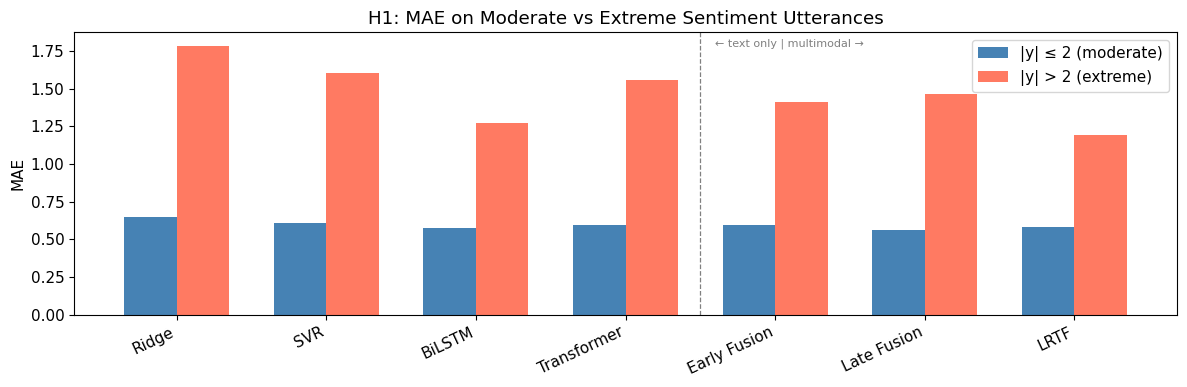

In [9]:
# Bar chart: moderate vs extreme MAE per model
model_list = [m for m in text_models + mm_models if m in all_results]
maes_mod   = [mae_fn(all_results[m]['preds'][moderate_mask], all_results[m]['labels'][moderate_mask])
              for m in model_list]
maes_ext   = [mae_fn(all_results[m]['preds'][extreme_mask],  all_results[m]['labels'][extreme_mask])
              for m in model_list]

x = np.arange(len(model_list))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, maes_mod, w, label='|y| ≤ 2 (moderate)', color='steelblue')
ax.bar(x + w/2, maes_ext, w, label='|y| > 2 (extreme)',  color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_list, rotation=25, ha='right')
ax.set_ylabel("MAE")
ax.set_title("H1: MAE on Moderate vs Extreme Sentiment Utterances")
ax.legend()
ax.axvline(len(text_models) - 0.5, color='grey', linestyle='--', linewidth=0.9)
ax.text(len(text_models) - 0.4, ax.get_ylim()[1] * 0.95,
        '← text only | multimodal →', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig("../figures/16_H1_extreme_mae.png", bbox_inches='tight')
plt.show()

### H2: Visual features are the least predictive of sentiment among the three modalities

=== H2: Unimodal sentiment prediction performance ===
Modality       MAE  Pearson r   Acc-2
--------------------------------------
Text        0.6170     0.6620  0.7942
Audio       0.8139     0.2407  0.6401
Visual      0.8076     0.2509  0.6425


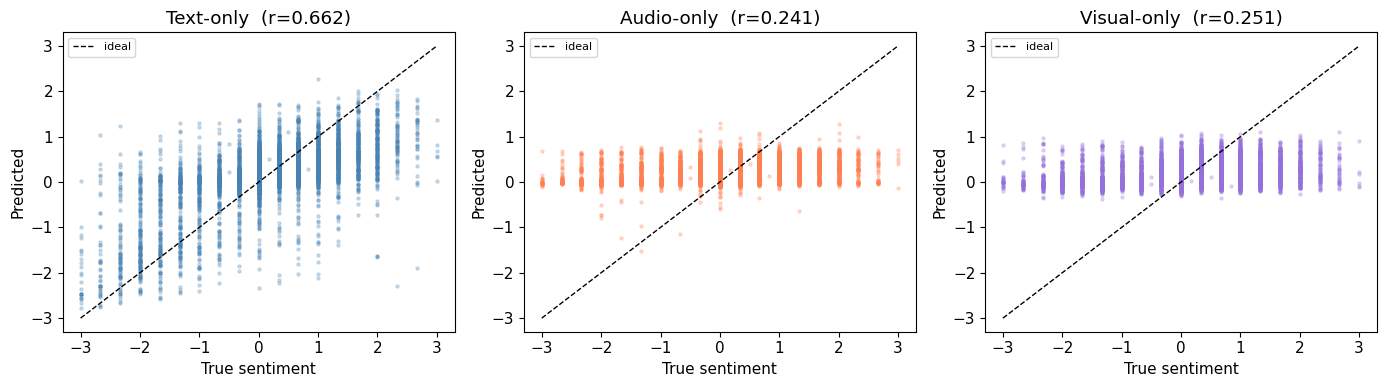

In [10]:
unimodal_names = ['BiLSTM', 'BiLSTM (audio)', 'BiLSTM (vision)']
labels_h2 = ['Text', 'Audio', 'Visual']

print("=== H2: Unimodal sentiment prediction performance ===")
print(f"{'Modality':<10} {'MAE':>7} {'Pearson r':>10} {'Acc-2':>7}")
print("-" * 38)
for name, label in zip(unimodal_names, labels_h2):
    p = all_results[name]['preds']
    l = all_results[name]['labels']
    mae  = np.mean(np.abs(p - l))
    corr = pearsonr(p, l)[0]
    nz   = l != 0
    acc2 = np.mean((p[nz]>0).astype(int) == (l[nz]>0).astype(int))
    print(f"{label:<10} {mae:>7.4f} {corr:>10.4f} {acc2:>7.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'coral', 'mediumpurple']
for ax, name, label, color in zip(axes, unimodal_names, labels_h2, colors):
    p = all_results[name]['preds']
    l = all_results[name]['labels']
    ax.scatter(l, p, alpha=0.25, s=5, color=color)
    ax.plot([-3,3],[-3,3],'k--',linewidth=1,label='ideal')
    r, _ = pearsonr(p, l)
    ax.set_title(f"{label}-only  (r={r:.3f})")
    ax.set_xlabel("True sentiment")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/15_H2_unimodal_scatter.png", bbox_inches='tight')
plt.show()

### H3: Text–visual disagreement increases with sentiment intensity

In [11]:
r_tv, p_tv = pearsonr(np.abs(labels), disagree_tv)
r_ta, p_ta = pearsonr(np.abs(labels), disagree_ta)

print("=== H3: Disagreement vs sentiment intensity ===")
print(f"  Text vs Visual  r={r_tv:+.4f}  p={p_tv:.4f}")
print(f"  Text vs Audio   r={r_ta:+.4f}  p={p_ta:.4f}")
print()
if r_tv > 0 and p_tv < 0.05:
    print("  H3 SUPPORTED: text-visual disagreement increases with intensity")
    print("  Interpretation: stronger emotions produce non-verbal expressions")
    print("  that diverge more from textual sentiment – visual cues add")
    print("  information text cannot convey at high emotional intensity.")
else:
    print("  H3 NOT SUPPORTED by text-visual comparison")

=== H3: Disagreement vs sentiment intensity ===
  Text vs Visual  r=+0.4523  p=0.0000
  Text vs Audio   r=+0.4629  p=0.0000

  H3 SUPPORTED: text-visual disagreement increases with intensity
  Interpretation: stronger emotions produce non-verbal expressions
  that diverge more from textual sentiment – visual cues add
  information text cannot convey at high emotional intensity.


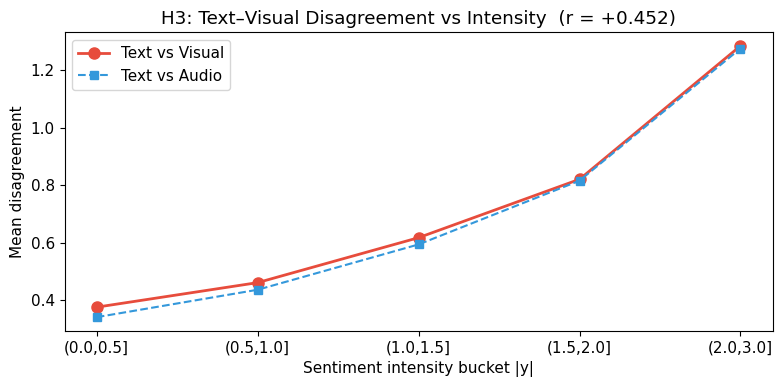

In [12]:
# Mean text-visual disagreement per intensity bucket (mirrors the line plot above)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bucket_labels, tv_means, 'o-', color='#e74c3c', linewidth=2, markersize=8,
        label='Text vs Visual')
ax.plot(bucket_labels, ta_means, 's--', color='#3498db', linewidth=1.5, markersize=6,
        label='Text vs Audio')
ax.set_xlabel("Sentiment intensity bucket |y|")
ax.set_ylabel("Mean disagreement")
ax.set_title(f"H3: Text–Visual Disagreement vs Intensity  (r = {r_tv:+.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/17_H3_disagreement_vs_intensity.png", bbox_inches='tight')
plt.show()

## 4. Sample-Level Case Study

Inspect high-disagreement utterances to understand *when* text and non-verbal cues diverge.

In [13]:
# Top-20 utterances with highest text–visual disagreement
top_idx = np.argsort(disagree_tv)[::-1][:20]

df_cases = pd.DataFrame({
    "True label":     np.round(labels[top_idx], 3),
    "Text pred":      np.round(preds_text[top_idx], 3),
    "Vision pred":    np.round(preds_vision[top_idx], 3),
    "TV disagreement":np.round(disagree_tv[top_idx], 3),
    "Text error":     np.round(np.abs(preds_text[top_idx]   - labels[top_idx]), 3),
    "Vision error":   np.round(np.abs(preds_vision[top_idx] - labels[top_idx]), 3),
})
print("Top-20 utterances with highest text–visual disagreement:")
print(df_cases.to_string())

Top-20 utterances with highest text–visual disagreement:
    True label  Text pred  Vision pred  TV disagreement  Text error  Vision error
0       -3.000     -2.564        0.807            3.371       0.436         3.807
1       -1.667     -2.542        0.609            3.151       0.875         2.276
2       -2.667     -2.375        0.723            3.098       0.291         3.389
3       -2.667     -2.302        0.773            3.075       0.364         3.440
4        0.333     -2.222        0.804            3.026       2.555         0.471
5       -1.667     -2.324        0.701            3.025       0.658         2.368
6       -2.333     -2.043        0.967            3.010       0.290         3.300
7       -2.333     -2.256        0.705            2.961       0.078         3.038
8       -2.333     -2.578        0.382            2.961       0.245         2.716
9       -1.667     -2.078        0.848            2.926       0.411         2.515
10      -0.667     -2.234        0.680   

## 5. Discussion Summary

*(Fill in the values once all cells have been executed)*

### Unimodal performance

| Model | MAE | Pearson r | Acc-2 |
|-------|-----|-----------|-------|
| Text BiLSTM | | | |
| Audio BiLSTM | | | |
| Vision BiLSTM | | | |

### Full results (all models)

| Model | MAE | Pearson r | Acc-2 | F1 |
|-------|-----|-----------|-------|----|
| Ridge | | | | |
| SVR | | | | |
| BiLSTM (text) | | | | |
| Transformer | | | | |
| Early Fusion | | | | |
| Late Fusion | | | | |
| LRTF | | | | |

### Hypothesis outcomes

**H1** – Text-only models underperform on extreme-sentiment utterances:  
*(report the ratio, e.g. "MAE on |y|>2 was 2.3× higher than on |y|≤2 for the best text model")*

**H2** – Visual features are the least predictive of sentiment:  
*(report unimodal MAE ranking: text < audio < visual)*

**H3** – Text–visual disagreement increases with sentiment intensity:  
*(report Pearson r between |label| and disagree_tv, and describe the per-bucket trend)*

### Overall conclusion

The three modalities carry complementary sentiment information. Text features alone provide a strong baseline, while audio and visual features offer the most additional signal for high-intensity utterances. Visual predictions diverge most from textual predictions at extreme sentiment values, suggesting that strong emotions elicit facial expressions that go beyond what the spoken words convey.